En este problema se desea segmentar las gotas medias y grandes de la siguiente imagen:
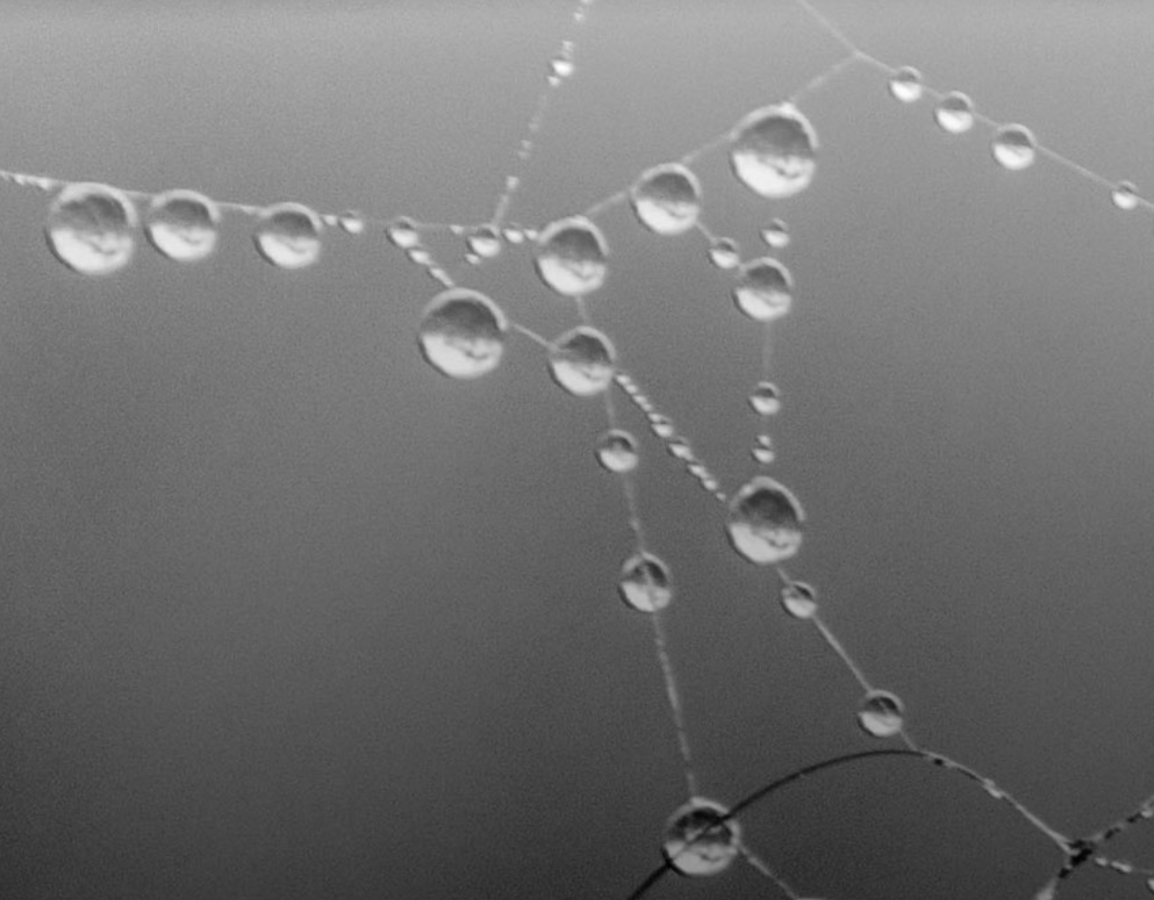

El output debe ser una imagen en la que se muestre la segmentación, aquí hay un ejemplo del resultado (no importa que la gota no sea segmentada completamente):

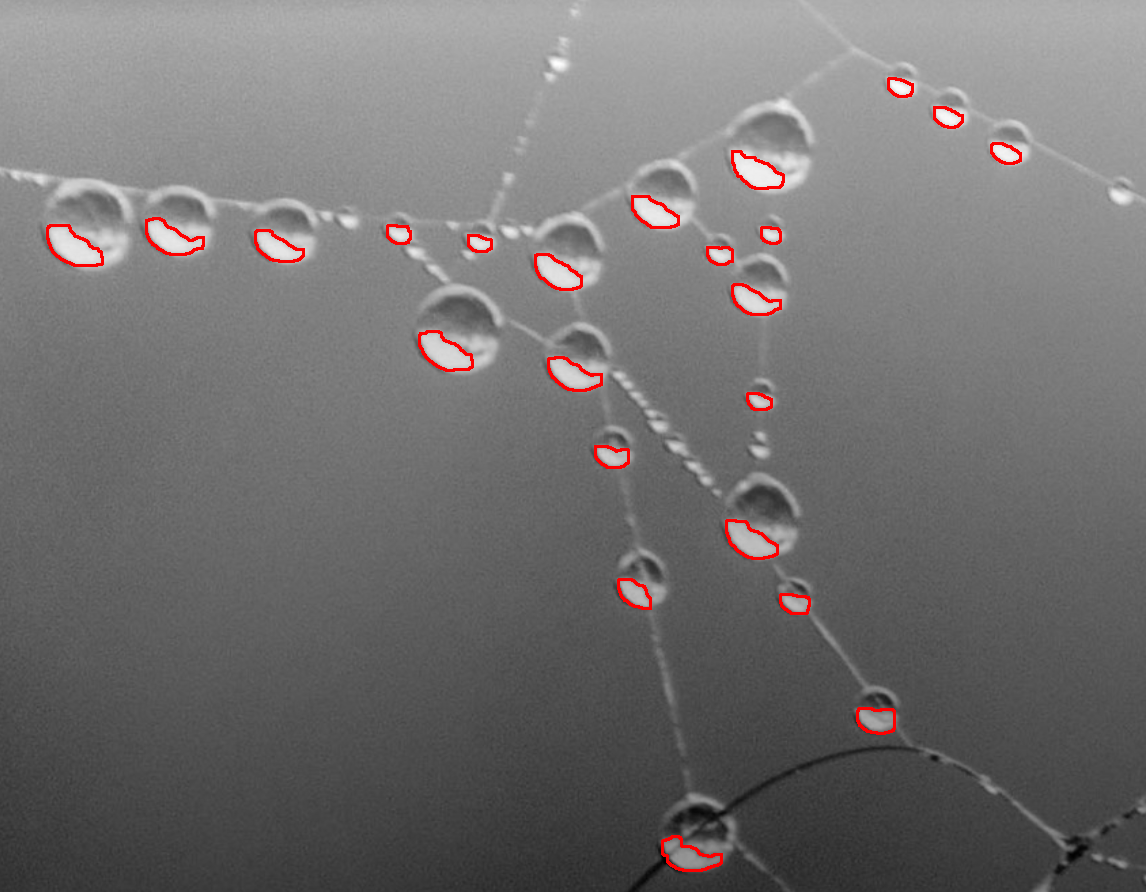

Para la solución se debe usar operaciones morfológicas. Se recomienda usar un filtro para eliminar la iluminación irregular, luego usar un umbral para detectar las zonas más claras y por último un filtro morfológico que elimine las regiones muy pequeñas. Soluciones que no consideren operaciones morfológicas no serán consideras.

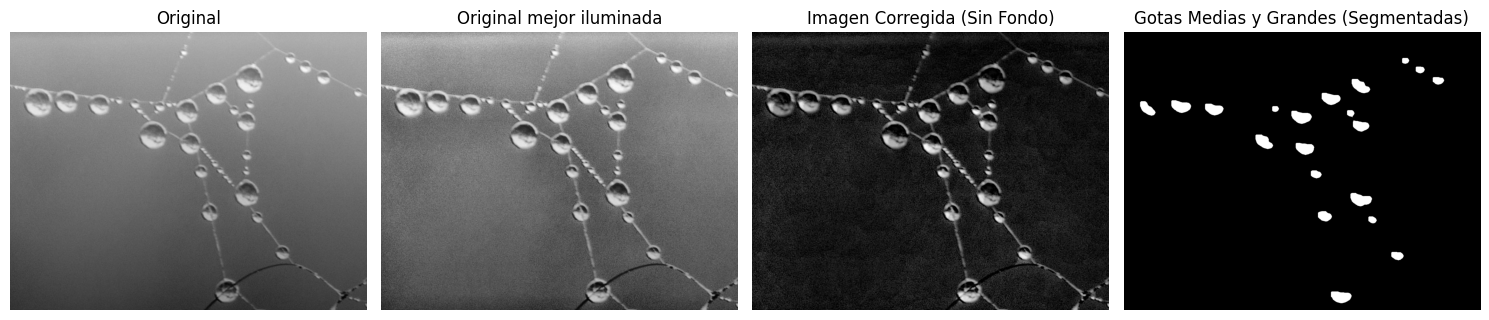

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Cargar la imagen en escala de grises
img_ori = cv2.imread('gotas.png', cv2.IMREAD_GRAYSCALE)

# 2. Filtro de Adaptativa (CLAHE) mejora el contraste de la imagen
equ = cv2.equalizeHist(img_ori)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
img = clahe.apply(img_ori)

# 3. APERTURA morfológica con un kernel grande para estimar el fondo (iluminación irregular)
# y luego lo resta de la imagen original para homogeneizar la iluminación y resaltar los objetos.
kernel = 50
kernel_fondo = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel, kernel))# barrer el contorno
fondo = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel_fondo)# apertura
# Restamos el fondo para homogeneizar
img_corregida = cv2.subtract(img, fondo)

# 4. Utilizamos el metodo de OTSU para binarizar la imagen de forma automática
_, img_binaria = cv2.threshold(img_corregida, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 5. GRADIENTE MORFOLOGICO para eliminar regiones pequeñas
# Definimos un elemento estructurante circular cv2.MORPH_ELLIPSE
# El tamaño del kernel (20x20) determina el tamaño de la gota que queremos segmentar
kernel = 20
kernel_limpieza = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel, kernel))

# 6. Aplicamos una APERTURA: Erosión (elimina puntos pequeños) seguida de Dilatación (restaura tamaño)
img_segmentada = cv2.morphologyEx(img_binaria, cv2.MORPH_OPEN, kernel_limpieza)

# 7. Un CIERRE para rellenar posibles huecos dentro de las gotas grandes
img_segmentada = cv2.morphologyEx(img_segmentada, cv2.MORPH_CLOSE, kernel_limpieza)

# 8. VISUALIZACIÓN DE RESULTADOS
plt.figure(figsize=(15, 10))

plt.subplot(1, 4, 1)
plt.title('Original')
plt.imshow(img_ori, cmap='gray')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.title('Original mejor iluminada')
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.title('Imagen Corregida (Sin Fondo)')
plt.imshow(img_corregida, cmap='gray')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.title('Gotas Medias y Grandes (Segmentadas)')
plt.imshow(img_segmentada, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

fin

otro

otro

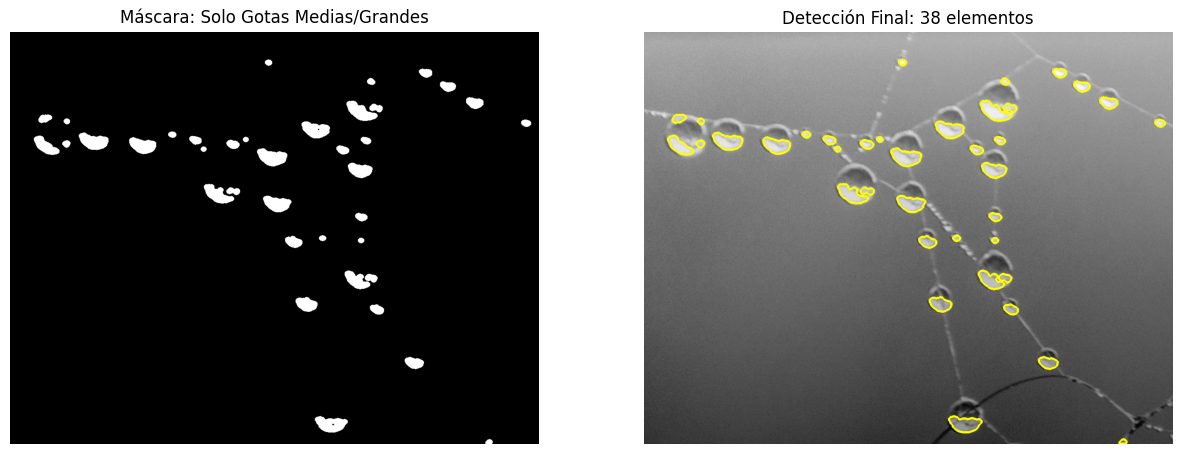

Análisis completado. Se detectaron 38 gotas significativas.


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Cargar imagen
img_color = cv2.imread('gotas.png')
img_gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)

# 2. ELIMINAR ILUMINACIÓN IRREGULAR (Top-Hat Morphological)
# Esto asegura que el fondo sea uniforme antes de la segmentación
kernel_iluminacion = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (40, 40))
fondo = cv2.morphologyEx(img_gray, cv2.MORPH_OPEN, kernel_iluminacion)
img_sin_fondo = cv2.subtract(img_gray, fondo)

# 3. UMBRALIZACIÓN (Otsu)
# Convertimos a blanco y negro
_, img_binaria = cv2.threshold(img_sin_fondo, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 4. FILTRO MORFOLÓGICO SELECTIVO (Apertura)
# Aumentamos el tamaño del kernel (ej. 13x13) para ser más estrictos.
# Solo las gotas medianas y grandes "sobrevivirán" a este tamaño.
kernel_selectivo = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (13, 13))
img_final = cv2.morphologyEx(img_binaria, cv2.MORPH_OPEN, kernel_selectivo)

# 5. DETECCIÓN Y CONTEO
contornos, _ = cv2.findContours(img_final, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Dibujar resultados
resultado_visual = img_color.copy()
cv2.drawContours(resultado_visual, contornos, -1, (0, 255, 255), 3) # Amarillo

# 6. MOSTRAR RESULTADOS
plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
plt.title("Máscara: Solo Gotas Medias/Grandes")
plt.imshow(img_final, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title(f"Detección Final: {len(contornos)} elementos")
plt.imshow(cv2.cvtColor(resultado_visual, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.show()

print(f"Análisis completado. Se detectaron {len(contornos)} gotas significativas.")

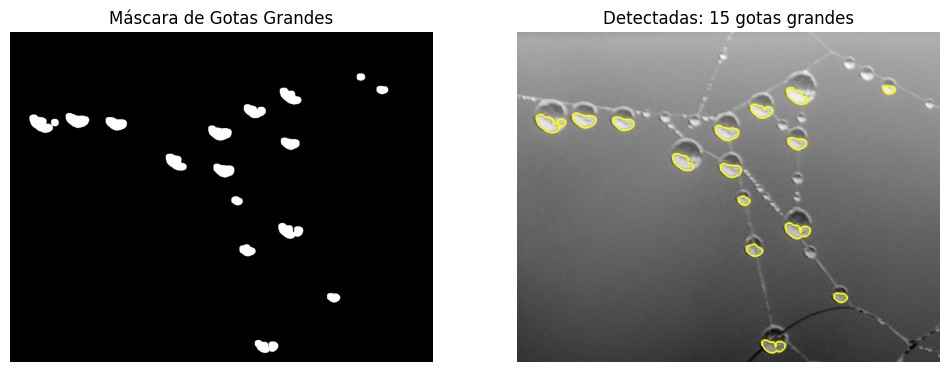

Se han identificado 15 gotas de gran tamaño.


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Cargar imagen y preparar versiones
img_color = cv2.imread('gotas.png')
img_gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)

# 2. CORRECCIÓN DE ILUMINACIÓN (Morfología de fondo)
# Elemento estructurante
ksize = 59  # tamaño del kernel (impar)
kernel_fondo = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (ksize, ksize))
# Estimamos el fondo para que las gotas resalten uniformemente
fondo = cv2.morphologyEx(img_gray, cv2.MORPH_OPEN, kernel_fondo)
img_sin_fondo = cv2.subtract(img_gray, fondo)

# 3. SEGMENTACION
# --- UMBRALIZACIÓN AUTOMÁTICA (Método Otsu) ---
# OpenCV calcula el umbral óptimo automáticamente al usar cv2.THRESH_OTSU
_, img_binaria = cv2.threshold(img_sin_fondo, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 4. FILTRADO MORFOLÓGICO
# Usamos un kernel 20x20
kernel = 20
kernel_grande = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel, kernel))
img_solo_grandes = cv2.morphologyEx(img_binaria, cv2.MORPH_OPEN, kernel_grande)

# 5. REFINAMIENTO POR AREA Y CONTEO
contornos_iniciales, _ = cv2.findContours(img_solo_grandes, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Definimos un área mínima (en píxeles) para asegurar que sean las más grandes
area_minima = 500
contornos_finales = [c for c in contornos_iniciales if cv2.contourArea(c) > area_minima]

# Contorno amarillo grueso
img_resultado = img_color.copy()
cv2.drawContours(img_resultado, contornos_finales, -1, (0, 255, 255), 3)

# 6. VISUALIZACION
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Máscara de Gotas Grandes")
plt.imshow(img_solo_grandes, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title(f"Detectadas: {len(contornos_finales)} gotas grandes")
plt.imshow(cv2.cvtColor(img_resultado, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.show()

print(f"Se han identificado {len(contornos_finales)} gotas de gran tamaño.")